In [1]:
import pandas as pd

path = r'C:\Users\gugel\OneDrive\Desktop\jianli\github\job-data-analysis\data\raw_data.csv'

# encoding_errors='replace' 是关键，它会跳过那个 0x80 字节
df = pd.read_csv(path, index_col=0, encoding='utf-8', encoding_errors='replace')

print("终于进来了！数据预览：")
print(df.head())

终于进来了！数据预览：
                                           Job Title  \
0  Data Analyst, Center on Immigration and Justic...   
1                               Quality Data Analyst   
2  Senior Data Analyst, Insights & Analytics Team...   
3                                       Data Analyst   
4                             Reporting Data Analyst   

              Salary Estimate  \
0  $37K-$66K (Glassdoor est.)   
1  $37K-$66K (Glassdoor est.)   
2  $37K-$66K (Glassdoor est.)   
3  $37K-$66K (Glassdoor est.)   
4  $37K-$66K (Glassdoor est.)   

                                     Job Description  Rating  \
0  Are you eager to roll up your sleeves and harn...     3.2   
1  Overview\n\nProvides analytical and technical ...     3.8   
2  We?�?re looking for a Senior Data Analyst who ...     3.4   
3  Requisition NumberRR-0001939\nRemote:Yes\nWe c...     4.1   
4  ABOUT FANDUEL GROUP\n\nFanDuel Group is a worl...     3.9   

                              Company Name      Location  Headquart

In [2]:
df['Salary Estimate'].head(10)

0    $37K-$66K (Glassdoor est.)
1    $37K-$66K (Glassdoor est.)
2    $37K-$66K (Glassdoor est.)
3    $37K-$66K (Glassdoor est.)
4    $37K-$66K (Glassdoor est.)
5    $37K-$66K (Glassdoor est.)
6    $37K-$66K (Glassdoor est.)
7    $37K-$66K (Glassdoor est.)
8    $37K-$66K (Glassdoor est.)
9    $37K-$66K (Glassdoor est.)
Name: Salary Estimate, dtype: object

In [3]:
def process_salary(s):
    try:
        s = s.replace('(Glassdoor est.)', '')
        s = s.replace('$', '').replace('K', '')
        low, high = s.split('-')
        return (float(low) + float(high)) / 2
    except:
        return None

In [4]:
df['salary_avg'] = df['Salary Estimate'].apply(process_salary)

In [5]:
df = df.dropna(subset=['salary_avg'])

In [6]:
df[['Salary Estimate', 'salary_avg']].head()

,Salary Estimate,salary_avg
0,$37K-$66K (Glassdoor est.),51.5
1,$37K-$66K (Glassdoor est.),51.5
2,$37K-$66K (Glassdoor est.),51.5
3,$37K-$66K (Glassdoor est.),51.5
4,$37K-$66K (Glassdoor est.),51.5


In [7]:
import matplotlib.pyplot as plt

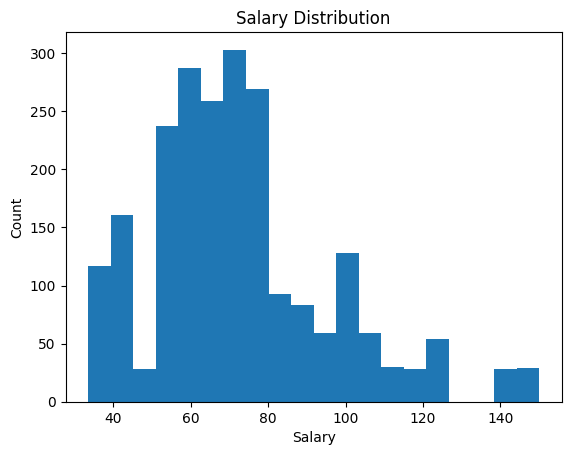

In [8]:
plt.hist(df['salary_avg'], bins=20)
plt.title('Salary Distribution')
plt.xlabel('Salary')
plt.ylabel('Count')
plt.savefig('../images/salary.png')
plt.show()

In [9]:
df.columns

Index(['Job Title', 'Salary Estimate', 'Job Description', 'Rating',
       'Company Name', 'Location', 'Headquarters', 'Size', 'Founded',
       'Type of ownership', 'Industry', 'Sector', 'Revenue', 'Competitors',
       'Easy Apply', 'salary_avg'],
      dtype='object')

In [10]:
df['Job Description'] = df['Job Description'].str.lower()

In [11]:
python_count = df['Job Description'].str.contains('python').sum()
sql_count = df['Job Description'].str.contains('sql').sum()

In [12]:
print('Python需求数量:', python_count)
print('SQL需求数量:', sql_count)

Python需求数量: 637
SQL需求数量: 1388


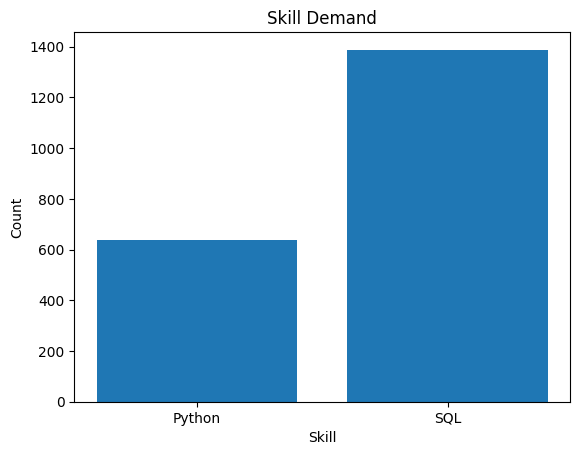

In [13]:
skills = ['Python', 'SQL']
counts = [python_count, sql_count]

plt.bar(skills, counts)
plt.title('Skill Demand')
plt.xlabel('Skill')
plt.ylabel('Count')
plt.savefig('../images/skills.png')
plt.show()

In [14]:
df['Location'].head(10)

0    New York, NY
1    New York, NY
2    New York, NY
3    New York, NY
4    New York, NY
5    New York, NY
6    New York, NY
7    New York, NY
8    New York, NY
9    New York, NY
Name: Location, dtype: object

In [15]:
df['city'] = df['Location'].apply(lambda x: x.split(',')[0])

In [16]:
city_salary = df.groupby('city')['salary_avg'].mean().sort_values(ascending=False)

In [17]:
city_salary.head(10)

city
Daly City            126.000000
Marin City           126.000000
Los Gatos            122.666667
Whittier             122.500000
Pico Rivera          122.500000
Berkeley             115.500000
Elk Grove Village    113.000000
Glenview             113.000000
Northfield           113.000000
Maywood              113.000000
Name: salary_avg, dtype: float64

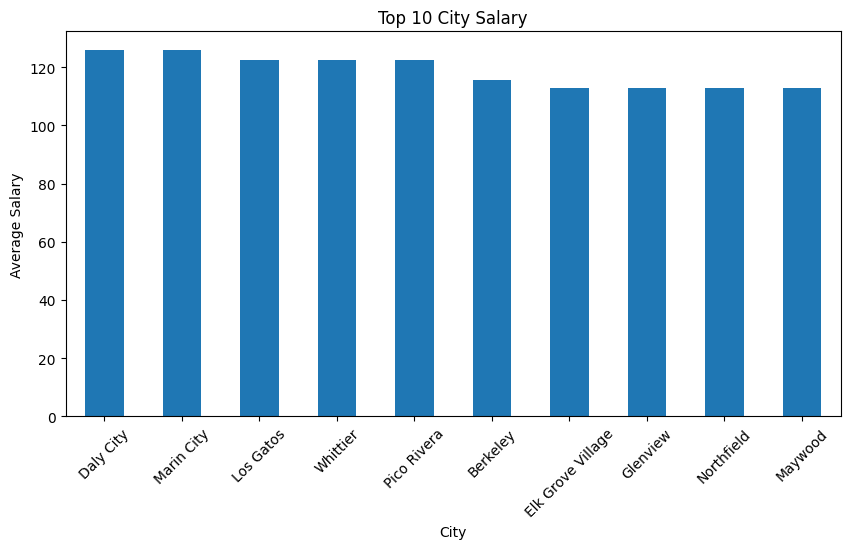

In [18]:
top10 = city_salary.head(10)

plt.figure(figsize=(10,5))
top10.plot(kind='bar')
plt.title('Top 10 City Salary')
plt.xlabel('City')
plt.ylabel('Average Salary')
plt.xticks(rotation=45)
plt.savefig('../images/city.png')
plt.show()